**Задание:** улучшить качество обучения.

Попробуйте добиться качества 0.992  на данном датасете  с минимальными изменениями архитектуры (в максимуме на валидации). 

 Обратите внимание на следующие моменты:

    Появляется ли у вас переобучение при увеличении количества эпох?
    Как добавление различных слоев влияет на скорость обучения (какие слои быстрее: сверточные или полносвязные)?

Помните, что результат обучения может меняться от запуска к запуску. Проанализируйте дисперсию целевой метрики от запуска к запуску. Сколько запусков достаточно произвести, перед тем как утверждать, что одна архитектура лучше другой?

In [49]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [50]:
import torchvision.datasets

In [51]:
MNIST_train = torchvision.datasets.MNIST('./', download=True, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=True, train=False)


In [52]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [53]:
len(y_train), len(y_test)

(60000, 10000)

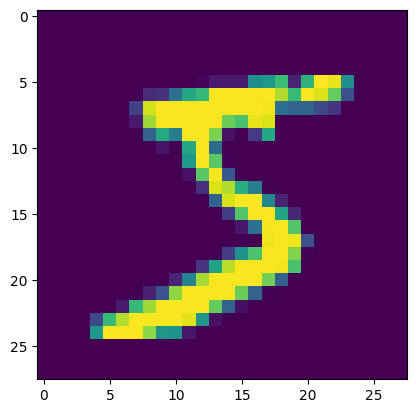

tensor(5)


In [54]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0, :, :])
plt.show()
print(y_train[0])

In [55]:
X_train = X_train.unsqueeze(1).float() / 255.0
X_test = X_test.unsqueeze(1).float() / 255.0

In [56]:
X_train.shape

torch.Size([60000, 1, 28, 28])

In [57]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        
        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)
       
        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()
        
        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()
        
        self.fc3   = torch.nn.Linear(84, 10)
    
    def forward(self, x):
        
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)
        
        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)
        
        return x
    
lenet5 = LeNet5()

In [58]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
lenet5 = lenet5.to(device)

In [59]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [60]:
# Добавить логгер Tensorboard
# 1. Сохранить результаты экспериментов при обучении сети.
# 2. Для каждого эксперимента должна быть одна и таже начальная инициализация.
from torch.utils.tensorboard import SummaryWriter

initial_state_dict = {k: v.clone() for k, v in lenet5.state_dict().items()}

writer = SummaryWriter(log_dir='runs/lab05_inclass_task')
lenet5.load_state_dict(initial_state_dict)

<All keys matched successfully>

In [61]:
batch_size = 100
num_epochs = 50

train_loss_history = []
test_accuracy_history = []
test_loss_history = []

X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(num_epochs):
    order = np.random.permutation(len(X_train))
    epoch_train_loss = 0.0
    num_batches = 0

    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()

        optimizer.step()

        epoch_train_loss += loss_value.item()
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches
    train_loss_history.append(avg_train_loss)

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    writer.add_scalar('train/loss', avg_train_loss, epoch)
    writer.add_scalar('test/loss', test_loss_history[-1], epoch)
    writer.add_scalar('test/accuracy', accuracy, epoch)

    print(accuracy)

writer.close()

tensor(0.9591)
tensor(0.9753)
tensor(0.9800)
tensor(0.9845)
tensor(0.9849)
tensor(0.9880)
tensor(0.9848)
tensor(0.9877)
tensor(0.9875)
tensor(0.9853)
tensor(0.9878)
tensor(0.9862)
tensor(0.9861)
tensor(0.9879)
tensor(0.9877)
tensor(0.9866)
tensor(0.9854)
tensor(0.9870)
tensor(0.9870)
tensor(0.9879)
tensor(0.9869)
tensor(0.9873)
tensor(0.9877)
tensor(0.9872)
tensor(0.9875)
tensor(0.9865)
tensor(0.9885)
tensor(0.9872)
tensor(0.9856)
tensor(0.9870)
tensor(0.9884)
tensor(0.9889)
tensor(0.9890)
tensor(0.9895)
tensor(0.9892)
tensor(0.9873)
tensor(0.9889)
tensor(0.9885)
tensor(0.9893)
tensor(0.9890)
tensor(0.9887)
tensor(0.9888)
tensor(0.9889)
tensor(0.9884)
tensor(0.9888)
tensor(0.9887)
tensor(0.9890)
tensor(0.9889)
tensor(0.9894)
tensor(0.9890)


In [62]:
lenet5.forward(X_test)

tensor([[ -1.4348,  -0.9181,  -2.0472,  ...,  24.8637,  -4.1298,   4.0240],
        [  1.6447,   0.8065,  25.1182,  ...,  -5.5430,   0.8667,  -4.2145],
        [ -3.8407,  23.3647,  -4.7398,  ...,   1.3684,   4.8839,  -7.4160],
        ...,
        [-10.8789,  -1.2721,  -6.4838,  ...,   0.4917,   0.1339,   4.4721],
        [ -4.7899,  -3.9050,  -9.3236,  ...,  -6.1414,   6.2626,  -5.4503],
        [  5.2122,  -6.9831,  -1.5221,  ..., -18.2870,   4.9928,  -3.3086]],
       grad_fn=<AddmmBackward0>)

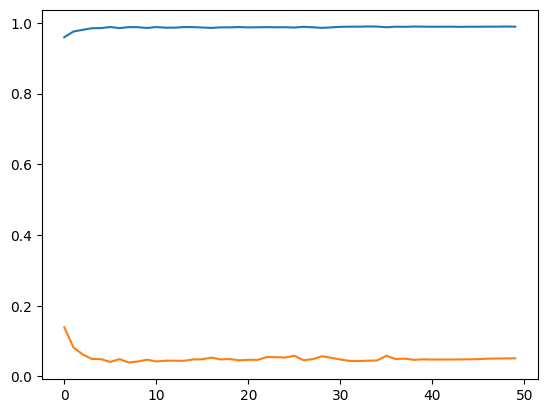

In [63]:
plt.plot(test_accuracy_history);
plt.plot(test_loss_history);

In [ ]:
# Визуализация TensorBoard
%load_ext tensorboard
%tensorboard --logdir runs/lab05_inclass_task --port 6006

In [64]:
%reload_ext tensorboard
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Could not find `tensorboard`. Please ensure that your PATH
contains an executable `tensorboard` program, or explicitly specify
the path to a TensorBoard binary by setting the `TENSORBOARD_BINARY`
environment variable.